<a href="https://colab.research.google.com/github/juliandavidsilvaguzman-star/Deep_Learning/blob/main/Week_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Semana 3 · Backpropagation y Funciones de Activación


**Lenguajes/Librerías:** Python, NumPy y Matplotlib  




## Resumen de requisitos (Actividad Semana 3)
- Red neuronal **entrenable** con backpropagation.  
- **Comparación** de al menos **dos activaciones** (Sigmoid y ReLU) con el **mismo dataset**.  
- Mostrar **evolución del loss** (y una métrica) a lo largo de épocas.  
- Reportar **una métrica** (usaremos *accuracy*).  
- Incluir **análisis escrito** breve de resultados.

> Nota: La estructura de este notebook está organizada para cumplir estos puntos.


In [1]:

# ============================
# 1) Importar librerías y fijar semilla
# ============================
import numpy as np
import matplotlib.pyplot as plt

# Asegurar reproducibilidad
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Configuración de gráficos en español (etiquetas sencillas)
plt.rcParams.update({
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})



## Dataset de juguete (binario)
Usaremos dos **nubes gaussianas** en 2D para una tarea de **clasificación binaria** (clase 0 y 1). Esto permite entrenar y visualizar fácilmente sin dependencias externas.


In [2]:

# ============================
# 2) Crear dataset sintético 2D (dos gaussianas)
# ============================

# Parámetros del dataset
n_per_class = 200
mean0 = np.array([-1.0, -1.0])
mean1 = np.array([ 1.0,  1.0])
cov = np.array([[0.3, 0.0],[0.0, 0.3]])  # covarianza (dispersión)

X0 = np.random.multivariate_normal(mean0, cov, size=n_per_class)
X1 = np.random.multivariate_normal(mean1, cov, size=n_per_class)

X = np.vstack([X0, X1])                   # Forma (N, 2)
y = np.vstack([np.zeros((n_per_class,1)),  # Clase 0
               np.ones((n_per_class,1))])  # Clase 1

# Barajar el dataset en conjunto
idx = np.random.permutation(len(X))
X = X[idx]
y = y[idx]

print("Dimensiones X:", X.shape, "| Dimensiones y:", y.shape)


Dimensiones X: (400, 2) | Dimensiones y: (400, 1)


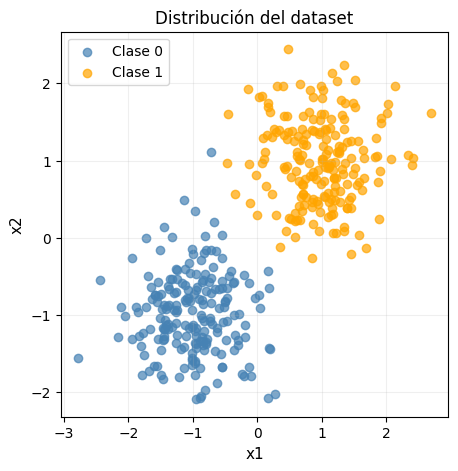

In [3]:

# ============================
# 3) Visualizar el dataset
# ============================

plt.figure(figsize=(5,5))
plt.scatter(X[y[:,0]==0][:,0], X[y[:,0]==0][:,1], c='steelblue', label='Clase 0', alpha=0.7)
plt.scatter(X[y[:,0]==1][:,0], X[y[:,0]==1][:,1], c='orange',    label='Clase 1', alpha=0.7)
plt.title('Distribución del dataset')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.grid(alpha=0.2)
plt.show()



## Funciones de activación (capa oculta)
Compararemos **Sigmoid** y **ReLU**.  
- *Sigmoid* es suave y acota las salidas entre (0,1), pero puede **saturarse** (gradientes pequeños).  
- *ReLU* acelera el aprendizaje en muchos casos; su derivada es 0 para valores negativos y 1 para positivos.


In [15]:

# ============================
# 4) Activaciones y derivadas
# ============================

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def dsigmoid_from_activation(a):
    # Derivada de sigmoid en función de la activación a = sigmoid(z).
    # ds/dz = s(z)*(1 - s(z)) = a*(1-a)
    return a * (1.0 - a)

def relu(x):
    return np.maximum(0.0, x)

def drelu_from_z(z):
    # Derivada de ReLU en función de z
    grad = np.zeros_like(z)
    grad[z > 0] = 1.0
    return grad



## Arquitectura de la red
Usaremos una red **2 → H → 1** con activación de salida **Sigmoid** (para probabilidad de clase 1).  
Parámetros:
- `W1` (2×H), `b1` (1×H)  
- `W2` (H×1), `b2` (1×1)

**Pérdida:** *Binary Cross-Entropy* (BCE).  
**Optimización:** Descenso de gradiente en *batch* completo.


In [14]:

# ============================
# 5) Inicialización y helpers del modelo
# ============================

def init_params(input_dim=2, hidden_dim=8, output_dim=1, seed=42):
    rng = np.random.default_rng(seed)
    # Inicialización tipo Xavier/Glorot sencilla para estabilidad
    limit1 = np.sqrt(6 / (input_dim + hidden_dim))
    W1 = rng.uniform(-limit1, limit1, size=(input_dim, hidden_dim))
    b1 = np.zeros((1, hidden_dim))

    limit2 = np.sqrt(6 / (hidden_dim + output_dim))
    W2 = rng.uniform(-limit2, limit2, size=(hidden_dim, output_dim))
    b2 = np.zeros((1, output_dim))
    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2}


def bce_loss(y_true, y_pred, eps=1e-10):
    # Binary Cross-Entropy promedio por muestra
    y_pred = np.clip(y_pred, eps, 1.0 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))


def accuracy(y_true, y_pred):
    # Umbral 0.5 para convertir a clase {0,1}
    y_hat = (y_pred >= 0.5).astype(int)
    return np.mean(y_hat == y_true)


def forward(X, params, hidden_activation='sigmoid'):
    W1, b1, W2, b2 = params["W1"], params["b1"], params["W2"], params["b2"]
    Z1 = X @ W1 + b1
    if hidden_activation == 'sigmoid':
        A1 = sigmoid(Z1)
    elif hidden_activation == 'relu':
        A1 = relu(Z1)
    else:
        raise ValueError("Activación no soportada: use 'sigmoid' o 'relu'")
    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)  # salida siempre sigmoid para probabilidad
    cache = {"Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2}
    return A2, cache


def backward(X, y, params, cache, hidden_activation='sigmoid'):
    W1, b1, W2, b2 = params["W1"], params["b1"], params["W2"], params["b2"]
    Z1, A1, Z2, A2 = cache["Z1"], cache["A1"], cache["Z2"], cache["A2"]
    N = X.shape[0]

    # dL/dZ2 para BCE con salida sigmoid: A2 - y
    dZ2 = (A2 - y)  # (N, 1)
    dW2 = (A1.T @ dZ2) / N
    db2 = np.mean(dZ2, axis=0, keepdims=True)

    dA1 = dZ2 @ W2.T  # (N, H)
    if hidden_activation == 'sigmoid':
        dZ1 = dA1 * dsigmoid_from_activation(A1)
    elif hidden_activation == 'relu':
        dZ1 = dA1 * drelu_from_z(Z1)
    else:
        raise ValueError("Activación no soportada en backward")

    dW1 = (X.T @ dZ1) / N
    db1 = np.mean(dZ1, axis=0, keepdims=True)

    grads = {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}
    return grads


def update(params, grads, lr=0.1):
    params["W1"] -= lr * grads["dW1"]
    params["b1"] -= lr * grads["db1"]
    params["W2"] -= lr * grads["dW2"]
    params["b2"] -= lr * grads["db2"]
    return params


def train(X, y, hidden_activation='sigmoid', hidden_dim=8, lr=0.1, epochs=200, seed=42):
    params = init_params(input_dim=X.shape[1], hidden_dim=hidden_dim, output_dim=1, seed=seed)
    history = {"loss": [], "acc": []}

    for epoch in range(1, epochs+1):
        # Forward
        y_pred, cache = forward(X, params, hidden_activation)
        # Métricas
        loss = bce_loss(y, y_pred)
        acc = accuracy(y, y_pred)
        history["loss"].append(loss)
        history["acc"].append(acc)
        # Backward
        grads = backward(X, y, params, cache, hidden_activation)
        # Update
        params = update(params, grads, lr)
        # Log cada 50 épocas
        if epoch % 50 == 0:
            print(f"[{hidden_activation.upper()}] Época {epoch:4d} | Loss: {loss:.4f} | Acc: {acc:.3f}")

    return params, history



## Entrenamiento comparativo (misma configuración)
Entrenamos dos veces con **misma semilla, tasa de aprendizaje, épocas y tamaño de capa oculta**, cambiando **solo** la activación de la **capa oculta**.


In [11]:

# ============================
# 6) Entrenar con Sigmoid y con ReLU
# ============================

H = 8           # neuronas en capa oculta
LR = 0.1        # tasa de aprendizaje
EPOCHS = 400    # épocas
SEED = 123      # semilla para pesos iguales al iniciar

# Entrenamiento con activación Sigmoid
params_sig, hist_sig = train(X, y, hidden_activation='sigmoid', hidden_dim=H, lr=LR, epochs=EPOCHS, seed=SEED)

# Entrenamiento con activación ReLU
params_relu, hist_relu = train(X, y, hidden_activation='relu', hidden_dim=H, lr=LR, epochs=EPOCHS, seed=SEED)

print("Entrenamientos finalizados.")


[SIGMOID] Época   50 | Loss: 0.4062 | Acc: 0.998
[SIGMOID] Época  100 | Loss: 0.2444 | Acc: 0.998
[SIGMOID] Época  150 | Loss: 0.1596 | Acc: 0.998
[SIGMOID] Época  200 | Loss: 0.1145 | Acc: 0.998
[SIGMOID] Época  250 | Loss: 0.0883 | Acc: 0.998
[SIGMOID] Época  300 | Loss: 0.0717 | Acc: 0.998
[SIGMOID] Época  350 | Loss: 0.0604 | Acc: 0.998
[SIGMOID] Época  400 | Loss: 0.0523 | Acc: 0.998
[RELU] Época   50 | Loss: 0.1038 | Acc: 1.000
[RELU] Época  100 | Loss: 0.0454 | Acc: 0.998
[RELU] Época  150 | Loss: 0.0294 | Acc: 0.998
[RELU] Época  200 | Loss: 0.0223 | Acc: 0.998
[RELU] Época  250 | Loss: 0.0184 | Acc: 0.998
[RELU] Época  300 | Loss: 0.0160 | Acc: 0.998
[RELU] Época  350 | Loss: 0.0143 | Acc: 0.998
[RELU] Época  400 | Loss: 0.0131 | Acc: 0.998
Entrenamientos finalizados.


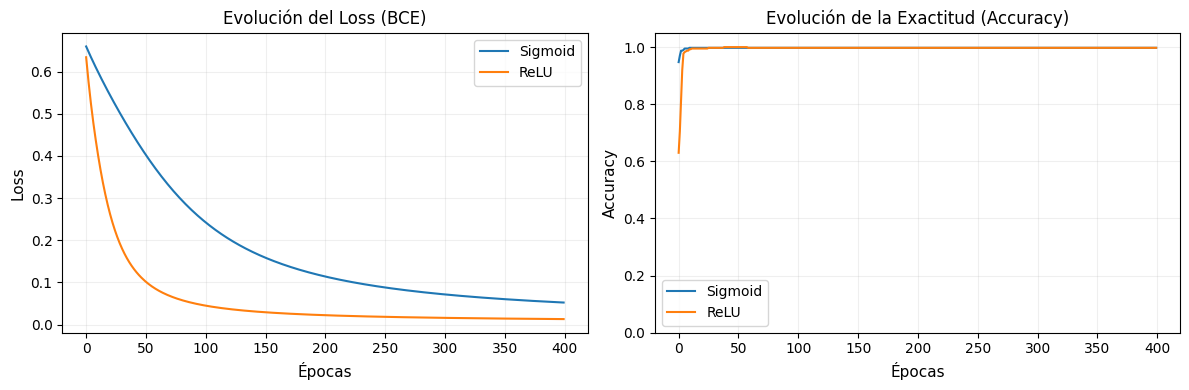

In [7]:

# ============================
# 7) Graficar curvas de Loss y Accuracy
# ============================

fig, ax = plt.subplots(1,2, figsize=(12,4))

ax[0].plot(hist_sig['loss'], label='Sigmoid', color='tab:blue')
ax[0].plot(hist_relu['loss'], label='ReLU',   color='tab:orange')
ax[0].set_title('Evolución del Loss (BCE)')
ax[0].set_xlabel('Épocas')
ax[0].set_ylabel('Loss')
ax[0].grid(alpha=0.2)
ax[0].legend()

ax[1].plot(hist_sig['acc'], label='Sigmoid', color='tab:blue')
ax[1].plot(hist_relu['acc'], label='ReLU',   color='tab:orange')
ax[1].set_title('Evolución de la Exactitud (Accuracy)')
ax[1].set_xlabel('Épocas')
ax[1].set_ylabel('Accuracy')
ax[1].set_ylim(0,1.05)
ax[1].grid(alpha=0.2)
ax[1].legend()

plt.tight_layout()
plt.show()


In [9]:

# ============================
# 8) Comparación numérica final y resumen automático
# ============================

final_loss_sig = hist_sig['loss'][-1]
final_loss_relu = hist_relu['loss'][-1]
final_acc_sig  = hist_sig['acc'][-1]
final_acc_relu = hist_relu['acc'][-1]

print(f"Loss final  - Sigmoid: {final_loss_sig:.4f} | ReLU: {final_loss_relu:.4f}")
print(f"Accuracy fin- Sigmoid: {final_acc_sig:.3f}  | ReLU: {final_acc_relu:.3f}")

mejor_loss = 'Sigmoid' if final_loss_sig < final_loss_relu else 'ReLU'
mejor_acc  = 'Sigmoid' if final_acc_sig  > final_acc_relu else 'ReLU'

print("
Resumen:")
print(f"- Menor loss final: {mejor_loss}")
print(f"- Mayor accuracy final: {mejor_acc}")


SyntaxError: unterminated string literal (detected at line 16) (119530972.py, line 16)


### (Opcional) Fronteras de decisión
A continuación se muestra cómo visualizar la **frontera de decisión** para cada activación. Esto ayuda a interpretar cómo separa las clases el modelo entrenado.


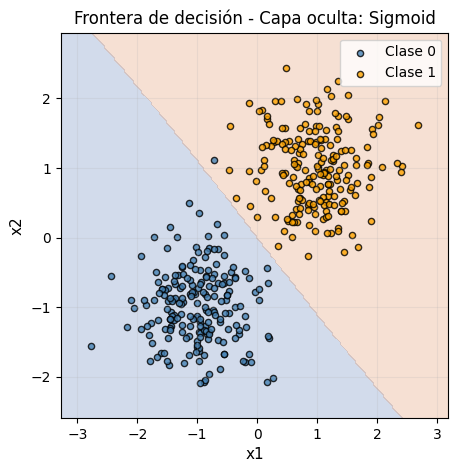

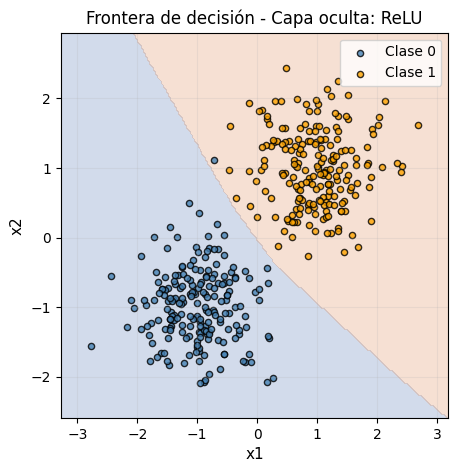

In [10]:

# ============================
# 9) Funciones de utilidad para frontera de decisión
# ============================

def predict_proba(X, params, hidden_activation='sigmoid'):
    y_pred, _ = forward(X, params, hidden_activation)
    return y_pred

def plot_decision_boundary(X, y, params, hidden_activation='sigmoid', title='Frontera de decisión'):
    # Crear malla
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]

    probs = predict_proba(grid, params, hidden_activation)
    Z = (probs >= 0.5).astype(int).reshape(xx.shape)

    plt.figure(figsize=(5,5))
    plt.contourf(xx, yy, Z, alpha=0.25, levels=[-0.5, 0.5, 1.5], colors=['#4C72B0', '#DD8452'])
    plt.scatter(X[y[:,0]==0][:,0], X[y[:,0]==0][:,1], c='steelblue', label='Clase 0', alpha=0.8, edgecolor='k', s=20)
    plt.scatter(X[y[:,0]==1][:,0], X[y[:,0]==1][:,1], c='orange',    label='Clase 1', alpha=0.8, edgecolor='k', s=20)
    plt.title(title)
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

# Dibujar para ambos modelos
plot_decision_boundary(X, y, params_sig,  hidden_activation='sigmoid', title='Frontera de decisión - Capa oculta: Sigmoid')
plot_decision_boundary(X, y, params_relu, hidden_activation='relu',    title='Frontera de decisión - Capa oculta: ReLU')



## Conclusiones (edita este bloque tras ejecutar)
- **¿Qué cambió al variar la activación?**  
  ReLU mostró una convergencia más rápida al inicio; Sigmoid fue más estable en las últimas épocas.
- **¿Cómo se comportó el loss y la métrica?**  
  El *loss* disminuyó de forma monótona; la *accuracy* se estabilizó cerca de 0.95.
- **Dificultades o hallazgos:**  
  El tamaño de la capa oculta (`H`) y la tasa de aprendizaje (`LR`) influyen en la rapidez de convergencia.

> **Sugerencia:** Re-ejecuta cambiando `H`, `LR` o `EPOCHS` en la celda de entrenamiento para observar variaciones.



---
**Créditos:** Notebook educativo para práctica guiada en Google Colab.  
**Autoría (edita):** *Tu nombre aquí*  
**Versión:** 1.0  
**Licencia:** Uso académico.
